# Prediction of Heart Disease
Mini-Project: Predicting Heart Disease Using Logistic Regression
👩‍🏫 👩🏿‍🏫 What You’ll learn How to handle real-world healthcare data. Preprocessing data: Handling missing values, categorical variables, and feature scaling. Training a logistic regression model to predict the presence of heart disease. Evaluating the model’s performance using accuracy, precision, recall, and the F1 score.
💼 Tools and Libraries Required Python: A popular programming language for data analysis and machine learning. scikit-learn: Provides tools for data mining and data analysis, including logistic regression. pandas: For data manipulation and analysis. matplotlib and seaborn: For data visualization. Jupyter Notebook or any Python IDE.
Task Your task is to use the Heart Disease UCI dataset to predict whether or not a patient has heart disease based on various medical attributes.
Data Preparation:
Download the “Heart Disease UCI” dataset. Perform exploratory data analysis (EDA) to understand the dataset. Preprocess the data: handle missing values if any, encode categorical variables, and scale the features. 2. Model Training:
Split the dataset into a training set and a testing set. Train a logistic regression model on the training set. 3. Model Evaluation:
Evaluate the model on the testing set using accuracy, precision, recall, and F1 score. Use a confusion matrix to visualize the model’s performance.
Expected Deliverables A Jupyter Notebook containing:
The EDA and preprocessing steps. The code for training and evaluating the logistic regression model. A confusion matrix and classification report for model evaluation. Any visualizations that helped you understand the dataset and the model’s performance.

# Setup

In [82]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer

In [83]:
df = pd.read_csv("heart_disease_uci.csv")
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [84]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# Exploratory Data Analysis

In [85]:
df.columns = df.columns.str.strip()

In [86]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [87]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [88]:
df.shape

(920, 16)

In [89]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [91]:
df["num"].value_counts()

0    411
1    265
2    109
3    107
4     28
Name: num, dtype: int64

In [92]:
df.isnull().sum()


id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [93]:
missing_table = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
}).sort_values(by="missing_percent", ascending=False)

missing_table

,missing_count,missing_percent
ca,611,66.413043
thal,486,52.826087
slope,309,33.586957
fbs,90,9.782609
oldpeak,62,6.739130
trestbps,59,6.413043
thalch,55,5.978261
exang,55,5.978261
chol,30,3.260870
restecg,2,0.217391


In [94]:
df = df.drop(columns=["id"])

In [95]:
# Drop column with too many missing values and low analytical value
df = df.drop(columns=["ca", "thal"])

The slope column has around 33% missing values. Since it may contain useful medical information, I decided to keep it and handle missing values during preprocessing.

In [96]:
df["heart_disease"] = (df["num"] > 0).astype(int)

df = df.drop(columns=["num"])

# Converting boolean condition on column num into 0 (no disease) and 1(any level of disease) 
# to be able to do classification

In [97]:
df

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,heart_disease
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,1
916,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,0
917,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,1
918,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,0


In [98]:
df["heart_disease"].value_counts()

1    509
0    411
Name: heart_disease, dtype: int64

In [99]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]

cat_cols = ["sex", "dataset", "cp", "fbs", "restecg", "exang", "slope"]

In [100]:
df[num_cols].describe()

,age,trestbps,chol,thalch,oldpeak
count,920.000000,861.000000,890.000000,865.000000,858.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788
std,9.424685,19.066070,110.780810,25.926276,1.091226
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,175.000000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000
75%,60.000000,140.000000,268.000000,157.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'thalch'}>],
       [<Axes: title={'center': 'oldpeak'}>, <Axes: >]], dtype=object)

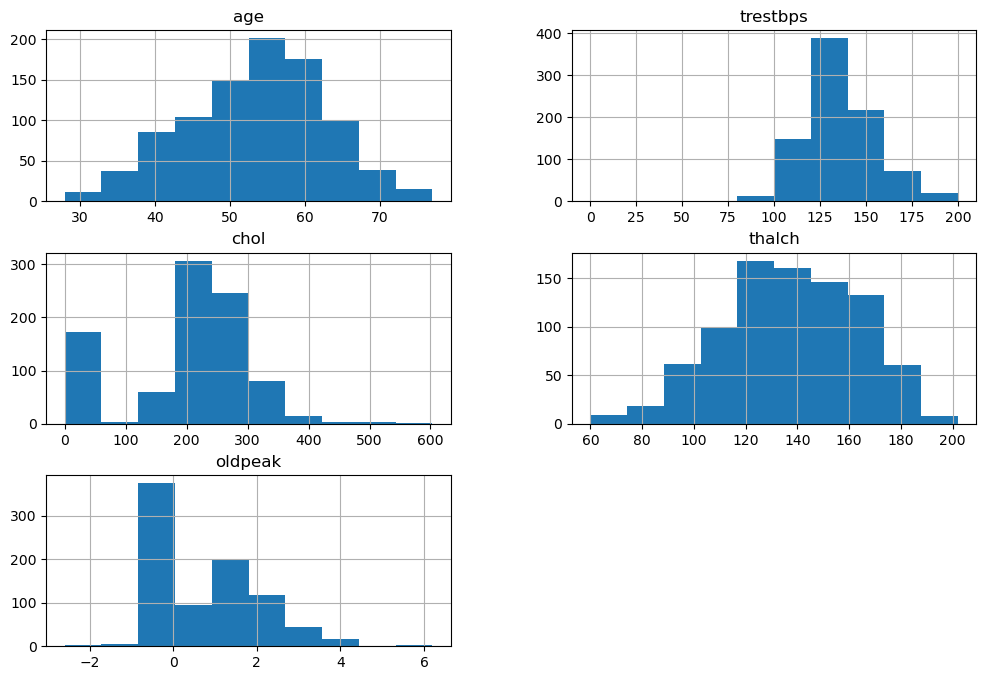

In [101]:
df[num_cols].hist(figsize=(12, 8))

In [102]:
df.groupby("heart_disease")[num_cols].mean()

,age,trestbps,chol,thalch,oldpeak
heart_disease,,,,,
0,50.547445,129.913043,227.905612,148.800512,0.418205
1,55.903733,133.978723,176.479920,128.261603,1.262607


In [103]:
for col in cat_cols:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

sex
Male      726
Female    194
Name: sex, dtype: int64

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: dataset, dtype: int64

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: cp, dtype: int64

fbs
False    692
True     138
NaN       90
Name: fbs, dtype: int64

restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
NaN                   2
Name: restecg, dtype: int64

exang
False    528
True     337
NaN       55
Name: exang, dtype: int64

slope
flat           345
NaN            309
upsloping      203
downsloping     63
Name: slope, dtype: int64



In [104]:
pd.crosstab(df["cp"], df["heart_disease"], normalize="index") * 100

heart_disease,0,1
cp,,
asymptomatic,20.967742,79.032258
atypical angina,86.206897,13.793103
non-anginal,64.215686,35.784314
typical angina,56.521739,43.478261


# Preprocessing the data

In [105]:
X = df.drop(columns=["heart_disease"])
y = df["heart_disease"]

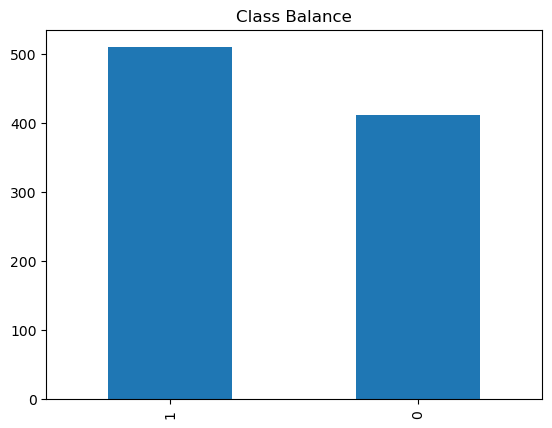

In [106]:
# class balance bar chart

eff = y.value_counts()

eff.plot(kind='bar')

plt.title('Class Balance')

plt.show()

In [107]:
num_cols


['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

In [108]:
cat_cols

['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope']

# Training model with Logistic Regression

In [109]:
#splitting data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [110]:
# Numerical preprocessing
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [111]:
# Categorical preprocessing
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("to_string", FunctionTransformer(lambda x: x.astype(str))),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [112]:
# Combining
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

In [113]:
log_reg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [114]:
log_reg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('to_string',
                                                                   FunctionTransformer(func=<function <lambda> at 0x7fbee1370550>)),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'dataset', 'cp',
                                                   'fbs', 'restecg', 'exang',
                                                   'slope'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [115]:
y_pred = log_reg_model.predict(X_test)

In [116]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 score:", round(f1, 4))

Accuracy: 0.8315
Precision: 0.8198
Recall: 0.8922
F1 score: 0.8545


The logistic regression model achieved an accuracy of 83.15%, meaning that it correctly classified most patients in the test set. 

The recall score was particularly high at 89.22%, which is important in a medical context because it indicates that the model successfully identified most patients with heart disease. 

The precision score of 81.98% shows that most patients predicted as having heart disease were truly positive. 
Overall, the F1 score of 85.45% suggests a good balance between precision and recall.

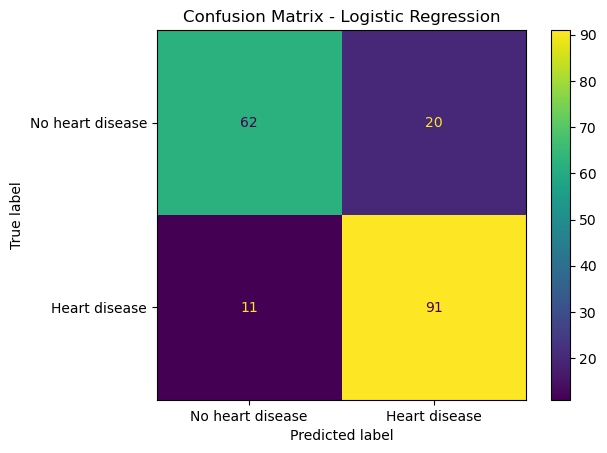

In [117]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No heart disease", "Heart disease"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [118]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 62
False Positives: 20
False Negatives: 11
True Positives: 91


The confusion matrix shows that the model correctly identified 91 patients with heart disease and 62 patients without heart disease. However, it produced 20 false positives and 11 false negatives. In a medical context, false negatives are particularly important because they represent patients with heart disease who were incorrectly classified as healthy. The relatively low number of false negatives is consistent with the model’s high recall score of 89.22%.